# 02 — Modelos SOTA, Métricas Clínicas & Interpretabilidade

Continuação do pipeline iniciado em `01_eda_dados.ipynb`

---

**Pré-requisito:** Ter corrido o notebook `01_eda_dados.ipynb` para que os ficheiros `data/MIQR-CC-Dataset/splits/train.csv`, `val.csv` e `test.csv` existam.

## 1. Imports e Configuração

In [ ]:
import os
import sys
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import glob
import pandas as pd
import shutil
from pathlib import Path
sys.path.append(os.path.join("..", "src"))
from preprocessing.data_setup import (
    MIQRDataset, 
    train_transforms, 
    train_transforms_strong, 
    val_transforms, 
    get_weighted_sampler     
)
from training.models import get_model
from training.train_wandb import TrainerWandb
from training.focal_loss import FocalLoss         
from training.early_stopping import EarlyStopping 
from evaluation.metrics import MetricsEvaluator
from evaluation.gradcam_utils import InterpretabilityTools, get_target_layers_for_model
from evaluation.noise_robustness import evaluate_robustness
from training.hyperparameter_search import run_grid_search
from evaluation.ensemble import (                  
    get_predictions_with_tta, 
    get_ensemble_predictions, 
    load_models_from_checkpoints
)

import wandb
wandb.login()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device em uso:', device)
DATA_DIR = os.path.join("..", "data", "MIQR-CC-Dataset")
TRAIN_CSV = os.path.join(DATA_DIR, "splits", "train.csv")
VAL_CSV   = os.path.join(DATA_DIR, "splits", "val.csv")
TEST_CSV  = os.path.join(DATA_DIR, "splits", "test.csv")
CLASS_NAMES = ['Biliary_Leaks', 'Lithiasis', 'Stricture', 'Normal']


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\tomas\_netrc.
wandb: Currently logged in as: laura-losa-ferreira (laura-losa-ferreira-universidade-do-minho) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Device em uso: cuda


In [2]:
import random

def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # para multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Seed global fixada para: {seed}")

# Executar logo no início
set_seed(42)


Seed global fixada para: 42


## 2. DataLoaders

Usa a classe `MIQRDataset` implementada (`src/data_setup.py`) que já aplica **CLAHE**, **Data Augmentation** e **Normalização ImageNet**.

In [3]:
# =====================================================================
# DATALOADERS MODULARES (Substituir a célula 3 do notebook)
# =====================================================================
BATCH_SIZE = 32

# INTERRUPTORES MODULARES - Muda para True ou False para testar!
USE_AUGMENTATION = True  # True: Augmentation V2 | False: Desativado V1
USE_BALANCED_SAMPLER = True     # True: WeightedRandomSampler | False: Shuffle normal

# 1. Escolher as transformações de treino
transforms_treino = train_transforms_strong if USE_AUGMENTATION else train_transforms
print(f"Data Augmentation de Treino: {'SIM (V2)' if USE_AUGMENTATION else 'NÃO (V1)'}")

# 2. Instanciar Datasets
dataset_treino = MIQRDataset(TRAIN_CSV, DATA_DIR, transform=transforms_treino)
dataset_val    = MIQRDataset(VAL_CSV,   DATA_DIR, transform=val_transforms)
dataset_teste  = MIQRDataset(TEST_CSV,  DATA_DIR, transform=val_transforms)

# 3. Configurar Sampler Balanceado
if USE_BALANCED_SAMPLER:
    sampler = get_weighted_sampler(dataset_treino)
    shuffle_treino = False
    CLASS_WEIGHTS=None
    print("WeightedRandomSampler ATIVADO (lotes equilibrados). Shuffle desativado.")
else:
    sampler = None
    CLASS_WEIGHTS = torch.tensor([2.4043, 0.5454, 1.0055, 1.3230], dtype=torch.float32).to(device)
    shuffle_treino = True
    print("WeightedRandomSampler DESATIVADO. Shuffle ativado.")

# 4. Criar Dataloaders
train_loader = DataLoader(dataset_treino, batch_size=BATCH_SIZE, sampler=sampler, shuffle=shuffle_treino, num_workers=2)
val_loader   = DataLoader(dataset_val,    batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(dataset_teste,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Treino:    {len(dataset_treino)} imagens | {len(train_loader)} batches")
print(f"Validação: {len(dataset_val)} imagens | {len(val_loader)} batches")
print(f"Teste:     {len(dataset_teste)} imagens | {len(test_loader)} batches")


Data Augmentation de Treino: SIM (V2)
WeightedRandomSampler ATIVADO (lotes equilibrados). Shuffle desativado.
Treino:    1106 imagens | 35 batches
Validação: 231 imagens | 8 batches
Teste:     231 imagens | 8 batches


### 2.1. Visualização de Data Augmentation em Tempo Real

Visualização de 4 amostras aleatórias de treino com as transformações ativas. **Cada vez que se corre a célula são apresentadas novas imagens e novas transformações aleatórias (rotação, zoom, brilho)**

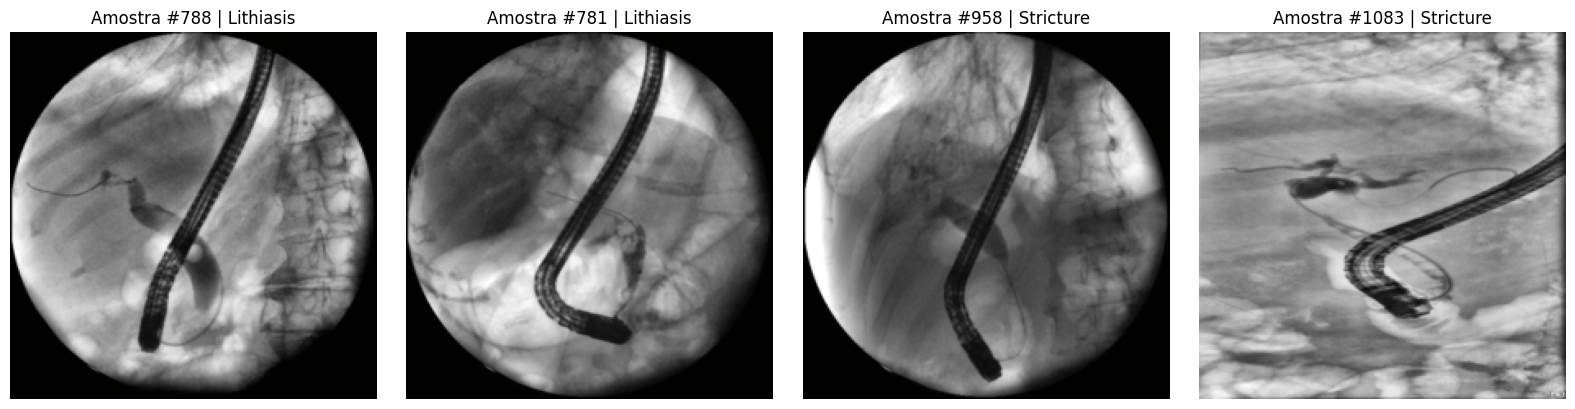

In [ ]:
# =====================================================================
# VISUALIZAÇÃO INTERATIVA DE DATA AUGMENTATION 
# =====================================================================
import random
import numpy as np

def visualizar_batches_aumentados(dataset, num_amostras=4):
    # Escolher índices aleatórios
    indices = random.sample(range(len(dataset)), num_amostras)
    
    plt.figure(figsize=(16, 4))
    
    # Parâmetros de desnormalização ImageNet
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    for i, idx in enumerate(indices):
        # Obter a imagem transformada do dataset
        img_tensor, label_idx = dataset[idx]
        
        # Converter tensor para numpy e reverter a normalização
        img_np = img_tensor.permute(1, 2, 0).numpy()
        img_np = std * img_np + mean
        img_np = np.clip(img_np, 0, 1) # Garantir valores válidos para matplotlib
        
        label_name = CLASS_NAMES[label_idx.item()]
        
        plt.subplot(1, num_amostras, i + 1)
        plt.imshow(img_np)
        plt.title(f"Amostra #{idx} | {label_name}")
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

# Executar a visualização com o dataset de treino atual
visualizar_batches_aumentados(dataset_treino)

## 3. Configuração dos Modelos SOTA e Treino com WandB

Treino dos diferentes modelos: 

- `'densenet121'` —  **Recomendado para raio-X** (arquitetura do CheXNet, Stanford)
- `efficientnet_v2_s` 
- `'vit_b_16'` —  Vision Transformer (gera Attention Maps)





### densenet121

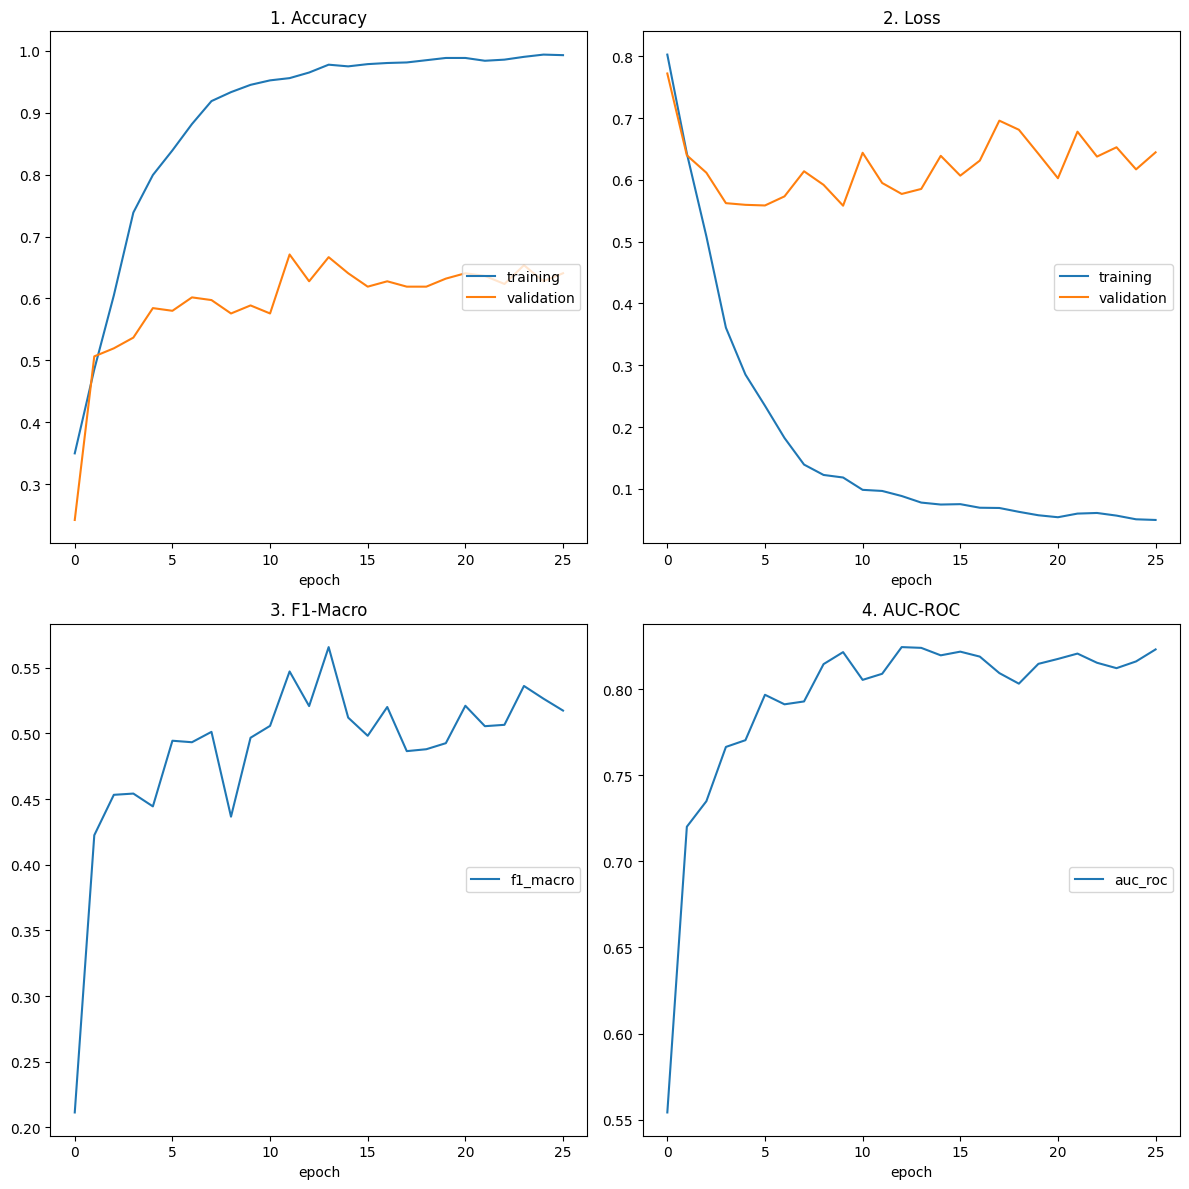

1. Accuracy
	training         	 (min:    0.350, max:    0.994, cur:    0.993)
	validation       	 (min:    0.242, max:    0.671, cur:    0.641)
2. Loss
	training         	 (min:    0.050, max:    0.803, cur:    0.050)
	validation       	 (min:    0.558, max:    0.772, cur:    0.645)
3. F1-Macro
	f1_macro         	 (min:    0.211, max:    0.566, cur:    0.517)
4. AUC-ROC
	auc_roc          	 (min:    0.554, max:    0.825, cur:    0.823)
EarlyStopping contador: 12 de 12 (Melhor score: 0.5657)

Paragem antecipada (Early Stopping) ativada na época 26!

Treino de densenet121 terminado. Melhor F1 Macro: 0.5657


auc_roc,▁▅▆▆▇▇▇▇██████████▇███████
epoch,▁▁▂▂▂▂▃▃▃▄▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
f1_macro,▁▅▆▆▆▇▇▇▅▇▇█▇█▇▇▇▆▆▇▇▇▇▇▇▇
learning_rate,██████▇▇▇▇▆▆▆▅▅▅▄▄▃▃▃▂▂▂▁▁
train_acc,▁▂▄▅▆▆▇▇▇▇████████████████
train_loss,█▇▅▄▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▅▆▆▇▇▇▇▆▇▆█▇██▇▇▇▇▇█▇▇█▇█
val_loss,█▄▃▁▁▁▁▃▂▁▄▂▂▂▄▃▃▆▅▄▂▅▄▄▃▄
auc_roc,0.82323
epoch,26
f1_macro,0.51736


Treino de densenet121 concluído! Melhor F1-Macro Validação: 0.5657


In [ ]:
# =====================================================================
# TREINO DE MODELO 
# =====================================================================
MODEL_NAME = "densenet121"
FINE_TUNING = True  # False: Apenas treina a cabeça | True: Fine-tuning completo

# CONFIGURAÇÕES
USE_FOCAL_LOSS = True       # True: Focal Loss | False: Cross Entropy Ponderada
USE_EARLY_STOPPING = True   # True: Parar quando a validação estabilizar
GRAD_CLIP_VAL = 1.0         # Valor de clipping dos gradientes (0.0 para desligar)

EPOCHS = 35
LEARNING_RATE = 5e-5

print(f"A preparar treino de {MODEL_NAME}...")

# 1. Carregar Modelo
model = get_model(MODEL_NAME, num_classes=4, feature_extracting=(not FINE_TUNING))
model = model.to(device)

# 2. Configurar a Loss Function
if USE_FOCAL_LOSS:
    criterion = FocalLoss(alpha=CLASS_WEIGHTS, gamma=2.0, label_smoothing=0.1)
    print("Loss: Focal Loss ativa.")
else:
    criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS, label_smoothing=0.1)
    print("Loss: Cross Entropy ponderada ativa.")

# 3. Otimizador
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# 4. Configurar Early Stopping
if USE_EARLY_STOPPING:
    # Monitorizar 'max' do F1-Macro na validação
    early_stopper = EarlyStopping(patience=12, verbose=True, mode='max')
    print("Early Stopping ativado (patience = 12 épocas).")
else:
    early_stopper = None
    print("Early Stopping desativado.")

# 5. Iniciar treino com WandB
config_run = {
    "model_name": MODEL_NAME,
    "lr": LEARNING_RATE,
    "batch_size": BATCH_SIZE,
    "loss_type": "FocalLoss" if USE_FOCAL_LOSS else "CrossEntropy",
    "balanced_sampler": USE_BALANCED_SAMPLER,
    "strong_augmentation": USE_AUGMENTATION,
    "early_stopping": USE_EARLY_STOPPING,
    "grad_clip": GRAD_CLIP_VAL
}

trainer = TrainerWandb(model, train_loader, val_loader, criterion, optimizer, device, CLASS_NAMES)
best_val_f1 = trainer.train_and_evaluate(
    config=config_run, 
    epochs=EPOCHS, 
    save_dir="checkpoints", 
    early_stopping=early_stopper,
    grad_clip=GRAD_CLIP_VAL
)
print(f"Treino de {MODEL_NAME} concluído! Melhor F1-Macro Validação: {best_val_f1:.4f}")


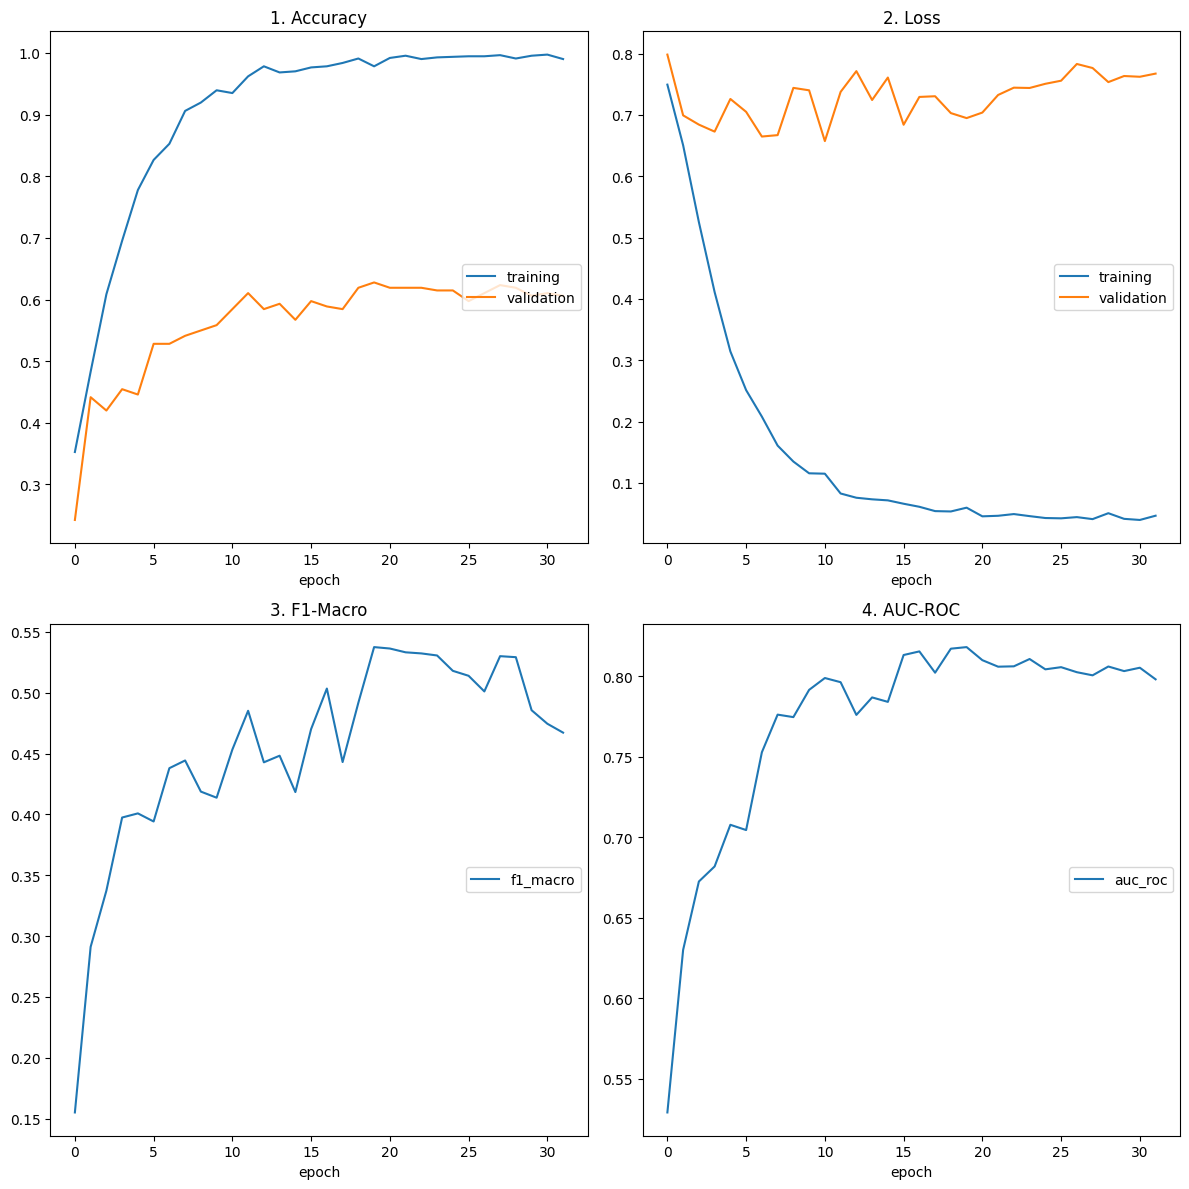

1. Accuracy
	training         	 (min:    0.353, max:    0.997, cur:    0.990)
	validation       	 (min:    0.242, max:    0.628, cur:    0.606)
2. Loss
	training         	 (min:    0.039, max:    0.750, cur:    0.046)
	validation       	 (min:    0.657, max:    0.799, cur:    0.768)
3. F1-Macro
	f1_macro         	 (min:    0.155, max:    0.538, cur:    0.467)
4. AUC-ROC
	auc_roc          	 (min:    0.529, max:    0.818, cur:    0.798)
EarlyStopping contador: 12 de 12 (Melhor score: 0.5376)

Paragem antecipada (Early Stopping) ativada na época 32!

Treino de efficientnet_v2_s terminado. Melhor F1 Macro: 0.5376


auc_roc,▁▃▄▅▅▅▆▇▇▇█▇▇▇▇█████████████████
epoch,▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇███
f1_macro,▁▃▄▅▅▅▆▆▆▆▆▇▆▆▆▇▇▆▇███████▇██▇▇▇
learning_rate,██████▇▇▇▇▇▆▆▆▆▅▅▅▄▄▄▃▃▃▂▂▂▂▁▁▁▁
train_acc,▁▂▄▅▆▆▆▇▇▇▇█████████████████████
train_loss,█▇▆▅▄▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▅▄▅▅▆▆▆▇▇▇█▇▇▇▇▇▇███████▇██████
val_loss,█▃▂▂▄▃▁▁▅▅▁▅▇▄▆▂▅▅▃▃▃▅▅▅▆▆▇▇▆▆▆▆
auc_roc,0.79804
epoch,32
f1_macro,0.46727


Treino de efficientnet_v2_s concluído! Melhor F1-Macro Validação: 0.5376


In [ ]:
# =====================================================================
# TREINO DE MODELO
# =====================================================================
MODEL_NAME = "efficientnet_v2_s"
FINE_TUNING = True  # False: Apenas treina a cabeça | True: Fine-tuning completo

# CONFIGURAÇÕES 
USE_FOCAL_LOSS = True       # True: Focal Loss | False: Cross Entropy Ponderada
USE_EARLY_STOPPING = True   # True: Parar quando a validação estabilizar
GRAD_CLIP_VAL = 1.0         # Valor de clipping dos gradientes (0.0 para desligar)

EPOCHS = 35
LEARNING_RATE = 5e-5

print(f"A preparar treino de {MODEL_NAME}...")

# 1. Carregar Modelo
model = get_model(MODEL_NAME, num_classes=4, feature_extracting=(not FINE_TUNING))
model = model.to(device)

# 2. Configurar a Loss Function
if USE_FOCAL_LOSS:
    criterion = FocalLoss(alpha=CLASS_WEIGHTS, gamma=2.0, label_smoothing=0.1)
    print("Loss: Focal Loss ativa.")
else:
    criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS, label_smoothing=0.1)
    print("Loss: Cross Entropy ponderada ativa.")

# 3. Otimizador
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# 4. Configurar Early Stopping
if USE_EARLY_STOPPING:
    # Monitorizar 'max' do F1-Macro na validação
    early_stopper = EarlyStopping(patience=12, verbose=True, mode='max')
    print("Early Stopping ativado (patience = 12 épocas).")
else:
    early_stopper = None
    print("Early Stopping desativado.")

# 5. Iniciar treino com WandB
config_run = {
    "model_name": MODEL_NAME,
    "lr": LEARNING_RATE,
    "batch_size": BATCH_SIZE,
    "loss_type": "FocalLoss" if USE_FOCAL_LOSS else "CrossEntropy",
    "balanced_sampler": USE_BALANCED_SAMPLER,
    "strong_augmentation": USE_AUGMENTATION,
    "early_stopping": USE_EARLY_STOPPING,
    "grad_clip": GRAD_CLIP_VAL
}

trainer = TrainerWandb(model, train_loader, val_loader, criterion, optimizer, device, CLASS_NAMES)
best_val_f1 = trainer.train_and_evaluate(
    config=config_run, 
    epochs=EPOCHS, 
    save_dir="checkpoints", 
    early_stopping=early_stopper,
    grad_clip=GRAD_CLIP_VAL
)
print(f"Treino de {MODEL_NAME} concluído! Melhor F1-Macro Validação: {best_val_f1:.4f}")


### vit_b_16

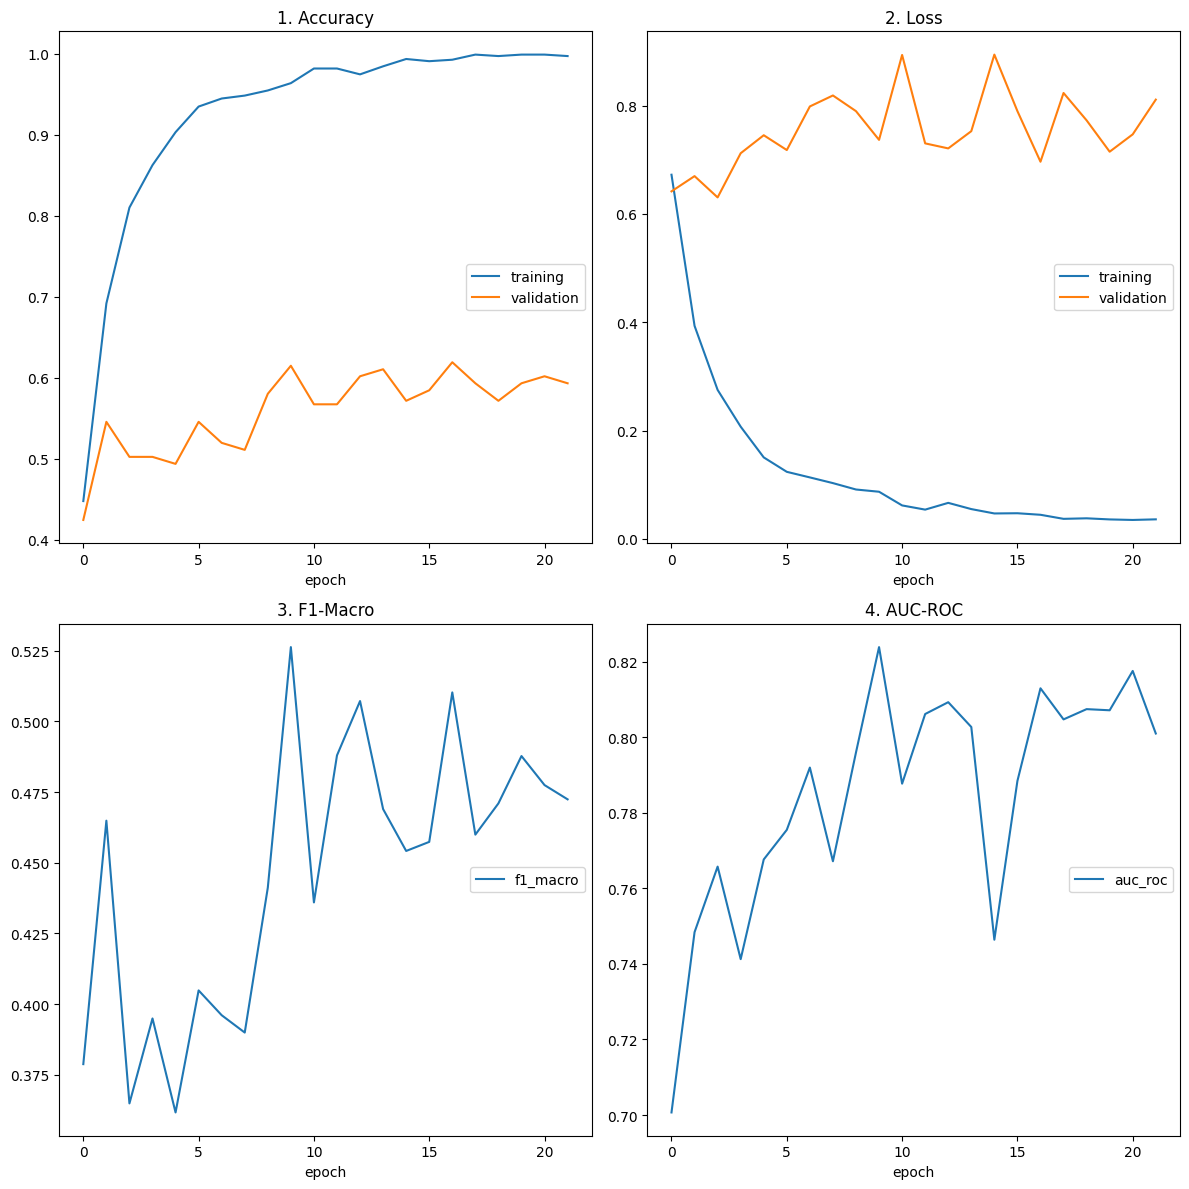

1. Accuracy
	training         	 (min:    0.448, max:    0.999, cur:    0.997)
	validation       	 (min:    0.424, max:    0.619, cur:    0.593)
2. Loss
	training         	 (min:    0.035, max:    0.672, cur:    0.036)
	validation       	 (min:    0.631, max:    0.894, cur:    0.811)
3. F1-Macro
	f1_macro         	 (min:    0.362, max:    0.526, cur:    0.472)
4. AUC-ROC
	auc_roc          	 (min:    0.701, max:    0.824, cur:    0.801)
EarlyStopping contador: 12 de 12 (Melhor score: 0.5263)

Paragem antecipada (Early Stopping) ativada na época 22!

Treino de vit_b_16 terminado. Melhor F1 Macro: 0.5263


auc_roc,▁▄▅▃▅▅▆▅▆█▆▇▇▇▄▆▇▇▇▇█▇
epoch,▁▁▂▂▂▃▃▃▄▄▄▅▅▅▆▆▆▇▇▇██
f1_macro,▂▅▁▂▁▃▂▂▄█▄▆▇▆▅▅▇▅▆▆▆▆
learning_rate,█████▇▇▇▇▆▆▆▅▅▄▄▃▃▂▂▁▁
train_acc,▁▄▆▆▇▇▇▇▇█████████████
train_loss,█▅▄▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▅▄▄▃▅▄▄▇█▆▆▇█▆▇█▇▆▇▇▇
val_loss,▁▂▁▃▄▃▅▆▅▄█▄▃▄█▅▃▆▅▃▄▆
auc_roc,0.80102
epoch,22
f1_macro,0.47245


Treino de vit_b_16 concluído! Melhor F1-Macro Validação: 0.5263


In [ ]:
# =====================================================================
# TREINO DE MODELO
# =====================================================================
MODEL_NAME = "vit_b_16"
FINE_TUNING = True  # False: Apenas treina a cabeça | True: Fine-tuning completo

# CONFIGURAÇÕES
USE_FOCAL_LOSS = True       # True: Focal Loss | False: Cross Entropy Ponderada
USE_EARLY_STOPPING = True   # True: Parar quando a validação estabilizar
GRAD_CLIP_VAL = 1.0         # Valor de clipping dos gradientes (0.0 para desligar)

EPOCHS = 35
LEARNING_RATE = 3e-5

print(f"A preparar treino de {MODEL_NAME}...")

# 1. Carregar Modelo
model = get_model(MODEL_NAME, num_classes=4, feature_extracting=(not FINE_TUNING))
model = model.to(device)

# 2. Configurar a Loss Function
if USE_FOCAL_LOSS:
    criterion = FocalLoss(alpha=CLASS_WEIGHTS, gamma=2.0, label_smoothing=0.1)
    print("Loss: Focal Loss ativa.")
else:
    criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS, label_smoothing=0.1)
    print("Loss: Cross Entropy ponderada ativa.")

# 3. Otimizador
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# 4. Configurar Early Stopping
if USE_EARLY_STOPPING:
    # Monitorizar 'max' do F1-Macro na validação
    early_stopper = EarlyStopping(patience=12, verbose=True, mode='max')
    print("Early Stopping ativado (patience = 12 épocas).")
else:
    early_stopper = None
    print("Early Stopping desativado.")

# 5. Iniciar treino com WandB
config_run = {
    "model_name": MODEL_NAME,
    "lr": LEARNING_RATE,
    "batch_size": BATCH_SIZE,
    "loss_type": "FocalLoss" if USE_FOCAL_LOSS else "CrossEntropy",
    "balanced_sampler": USE_BALANCED_SAMPLER,
    "strong_augmentation": USE_AUGMENTATION,
    "early_stopping": USE_EARLY_STOPPING,
    "grad_clip": GRAD_CLIP_VAL
}

trainer = TrainerWandb(model, train_loader, val_loader, criterion, optimizer, device, CLASS_NAMES)
best_val_f1 = trainer.train_and_evaluate(
    config=config_run, 
    epochs=EPOCHS, 
    save_dir="checkpoints", 
    early_stopping=early_stopper,
    grad_clip=GRAD_CLIP_VAL
)
print(f"Treino de {MODEL_NAME} concluído! Melhor F1-Macro Validação: {best_val_f1:.4f}")


## 4. Avaliação Final no Conjunto de Teste

Métricas obrigatórias: **F1-Score Macro**, **Matriz de Confusão**, **Curvas AUC-ROC**.

A avaliar densenet121 normal...

F1-Macro no Teste: 0.5077
AUC-ROC no Teste:  0.7913
               precision    recall  f1-score   support

Biliary_Leaks       0.75      0.16      0.26        19
    Lithiasis       0.61      0.70      0.65       109
    Stricture       0.60      0.60      0.60        58
       Normal       0.52      0.51      0.52        45

     accuracy                           0.59       231
    macro avg       0.62      0.49      0.51       231
 weighted avg       0.60      0.59      0.58       231



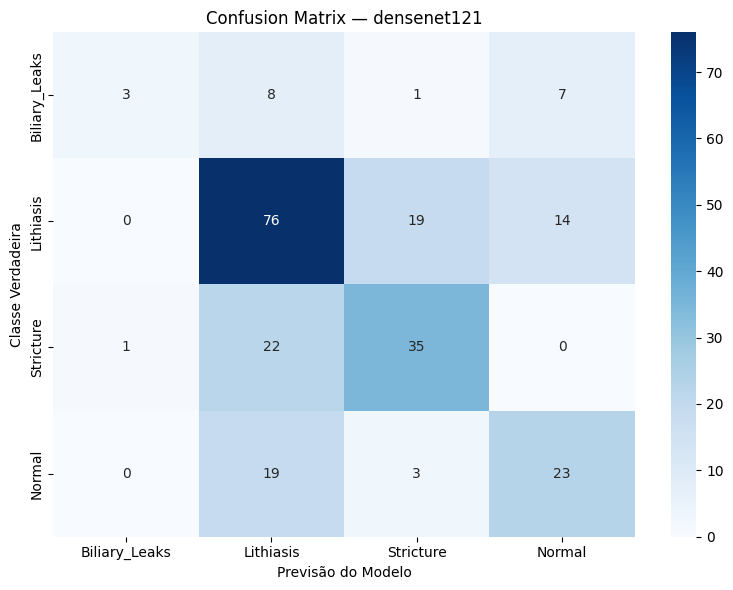

A avaliar efficientnet_v2_s normal...

F1-Macro no Teste: 0.5071
AUC-ROC no Teste:  0.8085
               precision    recall  f1-score   support

Biliary_Leaks       1.00      0.16      0.27        19
    Lithiasis       0.62      0.67      0.64       109
    Stricture       0.57      0.71      0.63        58
       Normal       0.53      0.44      0.48        45

     accuracy                           0.59       231
    macro avg       0.68      0.49      0.51       231
 weighted avg       0.62      0.59      0.58       231



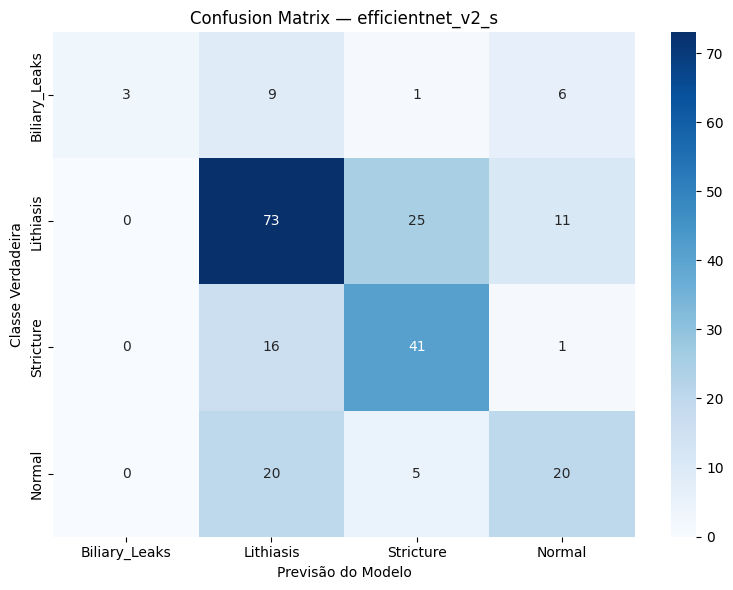

A avaliar vit_b_16 normal...

F1-Macro no Teste: 0.4477
AUC-ROC no Teste:  0.7887
               precision    recall  f1-score   support

Biliary_Leaks       0.67      0.11      0.18        19
    Lithiasis       0.56      0.78      0.65       109
    Stricture       0.65      0.41      0.51        58
       Normal       0.49      0.42      0.45        45

     accuracy                           0.56       231
    macro avg       0.59      0.43      0.45       231
 weighted avg       0.58      0.56      0.54       231



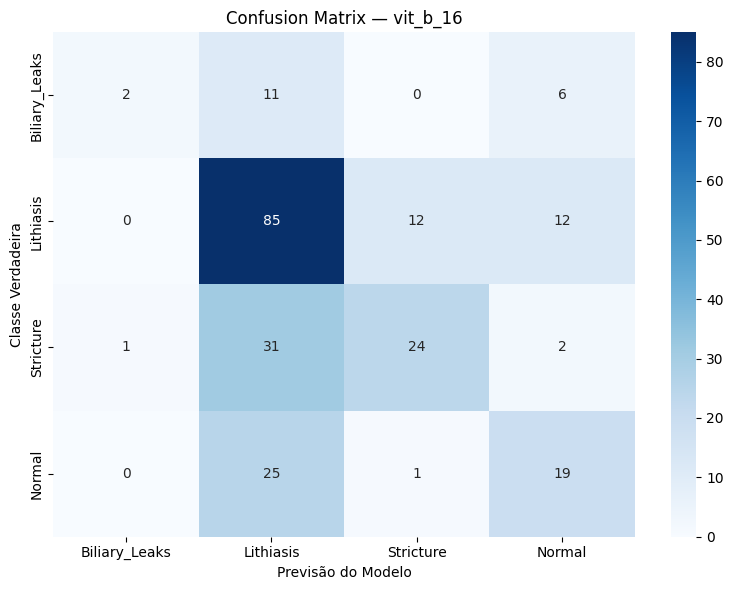

In [12]:
# =====================================================================
# AVALIAÇÃO DO MODELO
# =====================================================================
USE_TTA = False  # True para ativar TTA, False para avaliação padrão

# Procura todos os ficheiros .pth na pasta checkpoint
checkpoint_files = [str(caminho) for caminho in Path('checkpoints').glob('*.pth')]


if not checkpoint_files:
    print("Nenhum modelo encontrado na pasta 'checkpoints/'.")
else:
    for checkpoint_path in sorted(checkpoint_files):
        # 1. Carregar modelo do melhor checkpoint
        
        checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=True)
        model_name = checkpoint['model_name']
        model_eval = get_model(model_name, num_classes=4, feature_extracting=False)
        model_eval.load_state_dict(checkpoint['state_dict'])
        model_eval = model_eval.to(device)

        evaluator = MetricsEvaluator(CLASS_NAMES)

        # 2. Correr inferência
        if USE_TTA:
            print(f"A avaliar {model_name} no teste com Test-Time Augmentation (4 augmentações)...")
            test_probs, test_labels = get_predictions_with_tta(model_eval, test_loader, device, n_augments=4)
        else:
            print(f"A avaliar {model_name} normal...")
            all_probs, all_labels = [], []
            model_eval.eval()
            with torch.no_grad():
                for inputs, labels in test_loader:
                    outputs = model_eval(inputs.to(device))
                    probs = torch.softmax(outputs, dim=1)
                    all_probs.append(probs.cpu())
                    all_labels.append(labels.cpu())
            test_probs = torch.cat(all_probs)
            test_labels = torch.cat(all_labels)

        # 3. Mostrar métricas finais
        res = evaluator.evaluate(test_labels, test_probs)
        print(f"\nF1-Macro no Teste: {res['f1_macro']:.4f}")
        print(f"AUC-ROC no Teste:  {res['auc_roc']:.4f}")
        print(res['report'])

        # Mostrar e guardar Matriz de Confusão
        suffix = "_tta" if USE_TTA else "_normal"
        evaluator.plot_confusion_matrix(
            res['y_true'], 
            res['y_pred_labels'], 
            title=f"Confusion Matrix — {model_name}{' (TTA)' if USE_TTA else ''}",
            save_path=f"../outputs/confusion_matrix_{model_name}{suffix}.png"
        )


A carregar o modelo densenet121 de checkpoints\densenet121.pth...
A carregar o modelo efficientnet_v2_s de checkpoints\efficientnet_v2_s.pth...
A carregar o modelo vit_b_16 de checkpoints\vit_b_16.pth...
A calcular previsões do Ensemble (densenet121, efficientnet_v2_s, vit_b_16)...

  RESULTADOS DO ENSEMBLE
F1-Score Macro: 0.4970
AUC-ROC:        0.8317

Relatório de Classificação:
               precision    recall  f1-score   support

Biliary_Leaks       1.00      0.16      0.27        19
    Lithiasis       0.59      0.74      0.66       109
    Stricture       0.65      0.62      0.64        58
       Normal       0.47      0.38      0.42        45

     accuracy                           0.59       231
    macro avg       0.68      0.47      0.50       231
 weighted avg       0.62      0.59      0.57       231



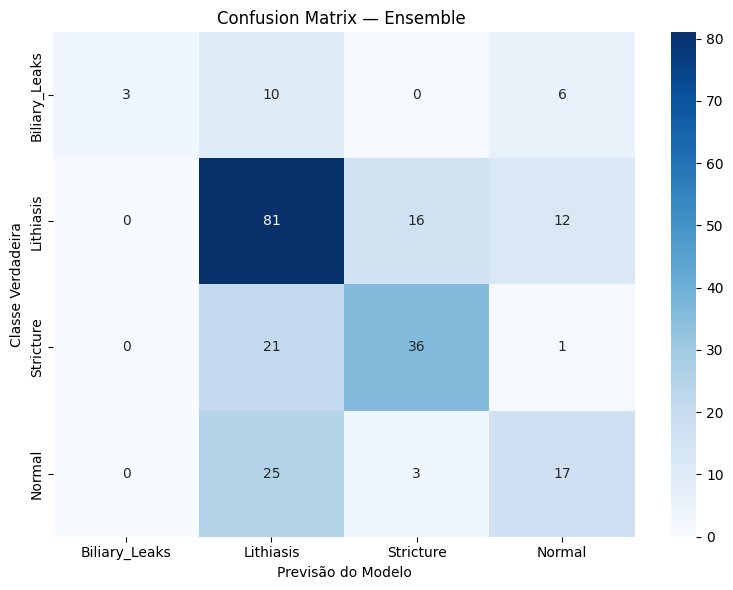

In [13]:
# =====================================================================
# AVALIAÇÃO DE ENSEMBLE DE MODELOS 
# =====================================================================

USE_TTA_IN_ENSEMBLE = False
modelos_ensemble=["densenet121","efficientnet_v2_s","vit_b_16"]
checkpoint_paths = [str(caminho) for caminho in Path('checkpoints').glob('*.pth')]


# 1. Carregar modelos
loaded_models = load_models_from_checkpoints(
    checkpoint_paths=checkpoint_paths,
    base_model_names=modelos_ensemble,
    num_classes=4,
    device=device
)

# 2. Obter probabilidades combinadas (média das previsões)
print(f"A calcular previsões do Ensemble ({', '.join(modelos_ensemble)})...")
ensemble_probs, test_labels = get_ensemble_predictions(
    models=loaded_models,
    dataloader=test_loader,
    device=device,
    use_tta=USE_TTA_IN_ENSEMBLE,
    n_augments=4
)

# 3. Avaliar
evaluator = MetricsEvaluator(CLASS_NAMES)
metrics_ens = evaluator.evaluate(test_labels, ensemble_probs)

print("\n" + "="*50)
print("  RESULTADOS DO ENSEMBLE")
print("="*50)
print(f"F1-Score Macro: {metrics_ens['f1_macro']:.4f}")
print(f"AUC-ROC:        {metrics_ens['auc_roc']:.4f}")
print("\nRelatório de Classificação:")
print(metrics_ens['report'])
print("="*50)

# 4. Desenhar e guardar gráficos do Ensemble
evaluator.plot_confusion_matrix(
    metrics_ens['y_true'], 
    metrics_ens['y_pred_labels'], 
    title="Confusion Matrix — Ensemble ",
    save_path="../outputs/confusion_matrix_ensemble.png"
)

evaluator.plot_roc_curves(
    metrics_ens['y_true'], 
    metrics_ens['probs'], 
    title="Curvas ROC — Ensemble",
    save_path="../outputs/roc_curves_ensemble.png"
)


## 5. Teste de Robustez ao Ruído

Avalia o modelo sob variações comuns em imagens de fluoroscopia:
ruído Gaussiano, variações de contraste e artefactos de pixels.

In [14]:
evaluator = MetricsEvaluator(CLASS_NAMES)
# 1. Encontrar todos os checkpoints válidos dos 4 modelos
checkpoint_files = [str(caminho) for caminho in Path('checkpoints').glob('*.pth')]
modelos_alvo=["densenet121","efficientnet_v2_s","vit_b_16"]

if not checkpoint_files:
    print("Nenhum modelo encontrado na pasta 'checkpoints/'.")
else:
    for ckpt_path in sorted(checkpoint_files):
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=True)
        nome_modelo = ckpt['model_name']
        nome_base = next((m for m in modelos_alvo if m in nome_modelo), nome_modelo)
        # Recriar o modelo e carregar os pesos
        temp_model = get_model(nome_base, num_classes=4, feature_extracting=False)
        temp_model.load_state_dict(ckpt['state_dict'])
        temp_model.to(device)
        temp_model.eval()
    
        print(f"\n--- Robustez: {nome_modelo} ---")
        robustness_results = evaluate_robustness(
            model=temp_model,
            test_loader=test_loader,
            evaluator=evaluator,
            device=device
        )
        



--- Robustez: densenet121 ---
Tipo de Ruído          F1-Macro   Degradação      AUC-ROC
------------------------------------------------------------
clean                    0.5077                    0.7913
gaussian                 0.1330      -0.3747       0.5818
contrast                 0.1471      -0.3606       0.5602
salt_pepper              0.2448      -0.2629       0.5896
combined                 0.0947      -0.4130       0.5864

--- Robustez: efficientnet_v2_s ---
Tipo de Ruído          F1-Macro   Degradação      AUC-ROC
------------------------------------------------------------
clean                    0.5071                    0.8085
gaussian                 0.3335      -0.1737       0.5822
contrast                 0.2846      -0.2225       0.5336
salt_pepper              0.0383      -0.4688       0.5059
combined                 0.2239      -0.2832       0.5938

--- Robustez: vit_b_16 ---
Tipo de Ruído          F1-Macro   Degradação      AUC-ROC
----------------------------

## 6. Interpretabilidade: Layer-CAM

 Gera heatmaps que mostram onde o modelo está a focar.

> Verifica se o foco está nos **ductos biliares** e não em artefactos externos.

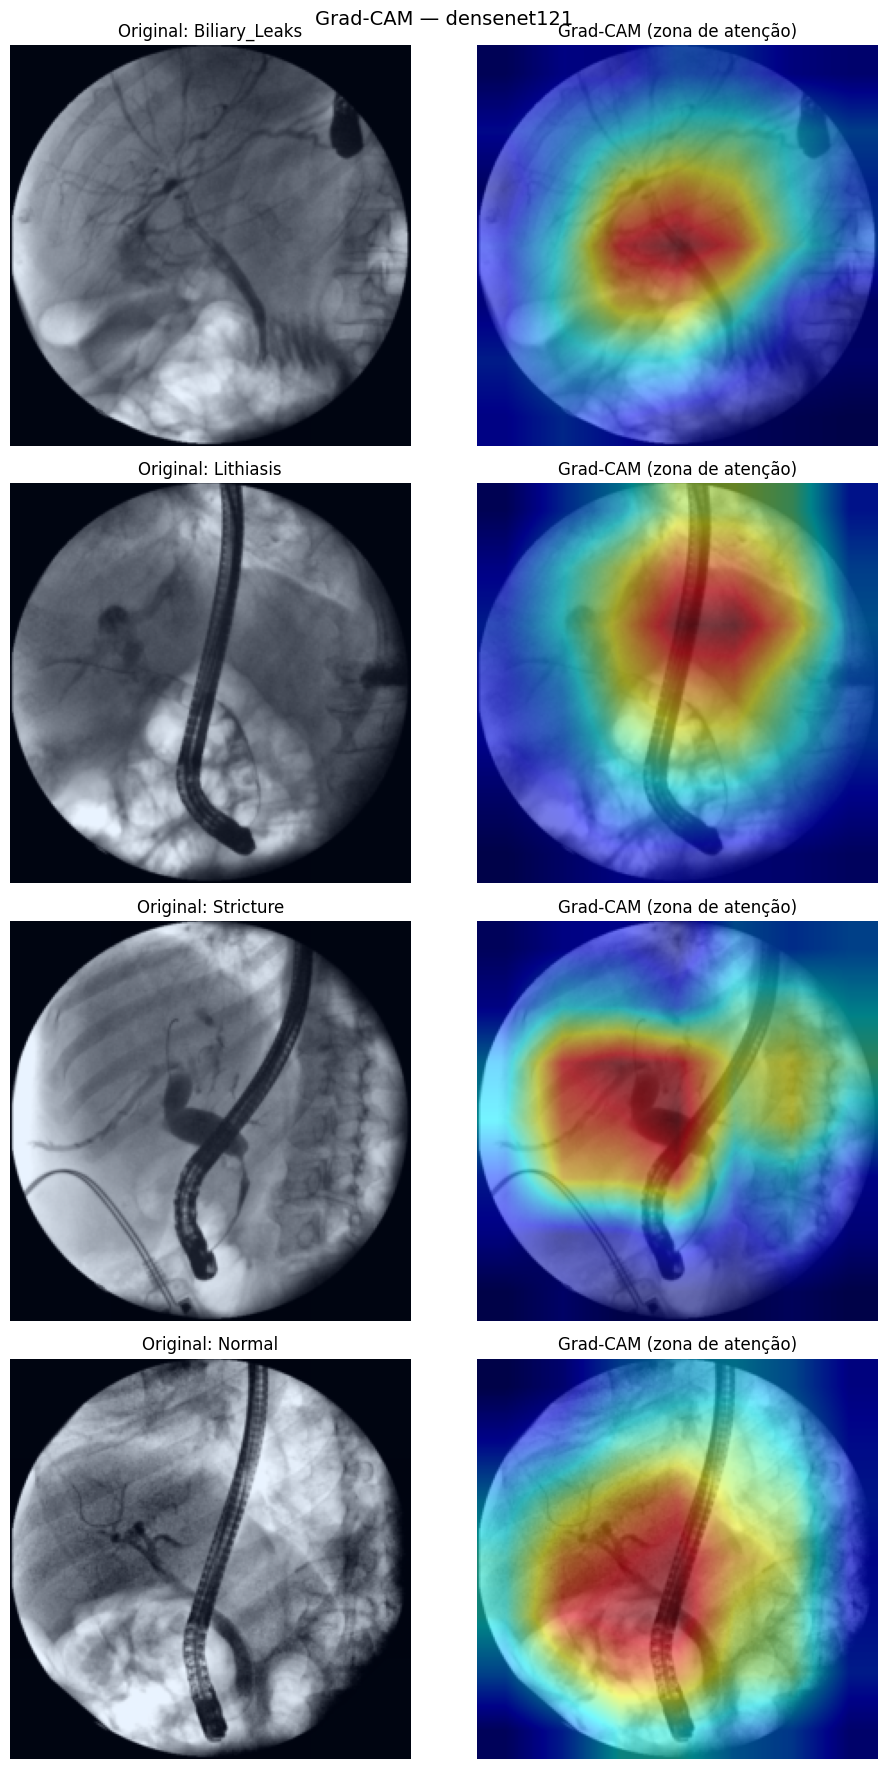

Heatmaps guardados em outputs/gradcam/


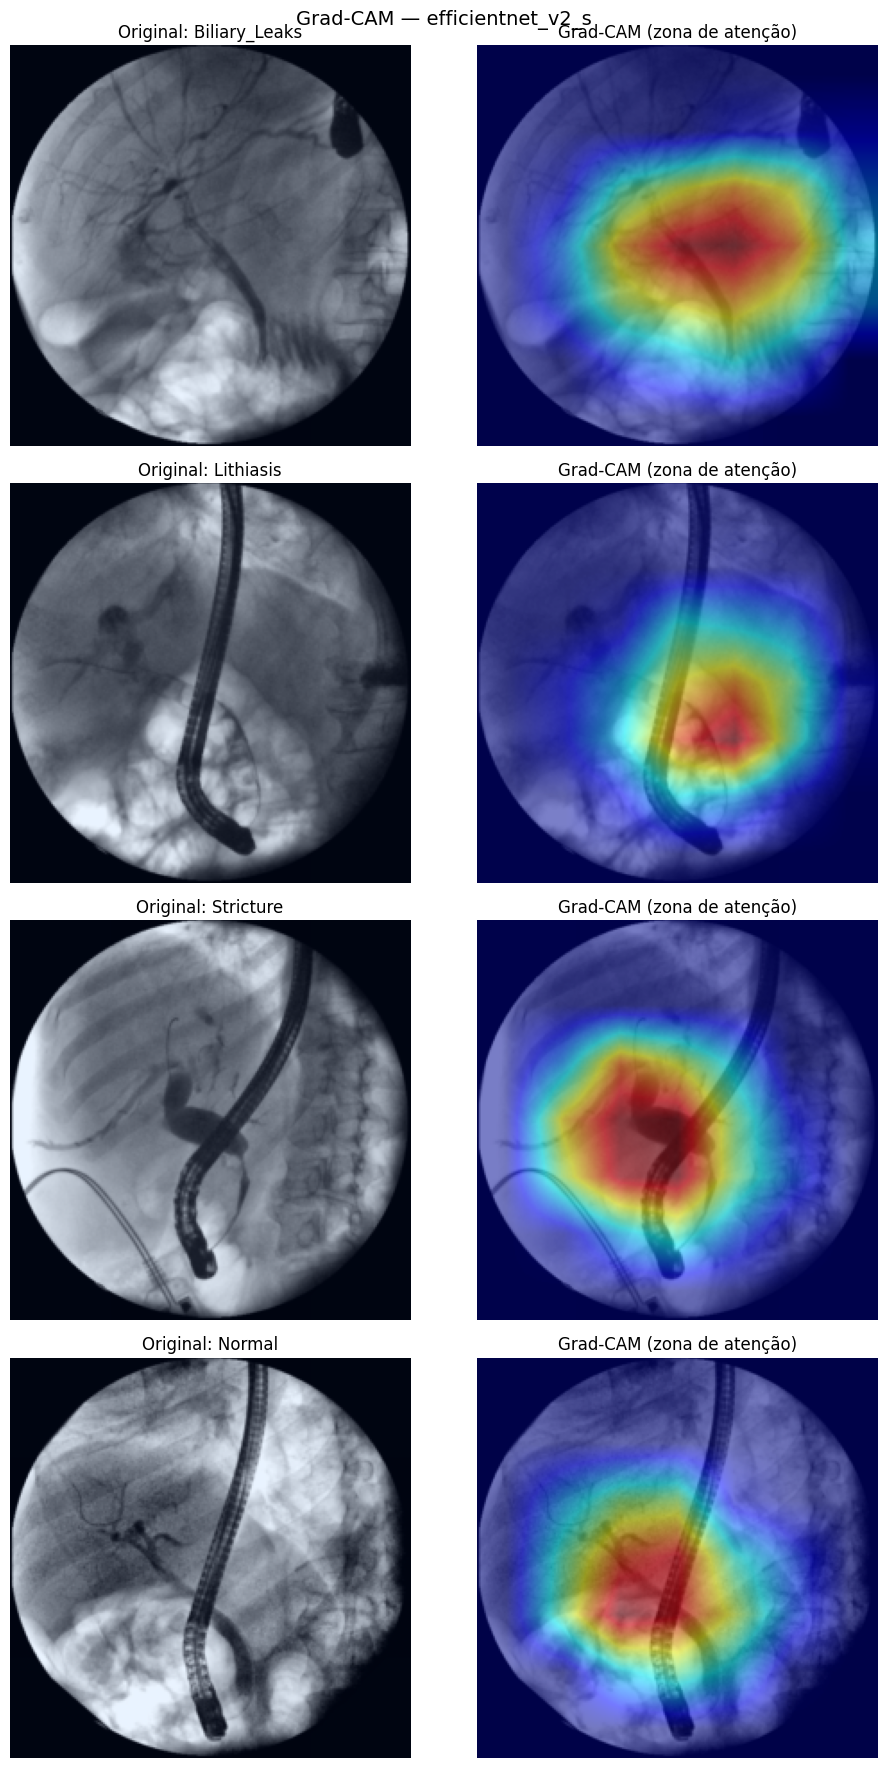

Heatmaps guardados em outputs/gradcam/


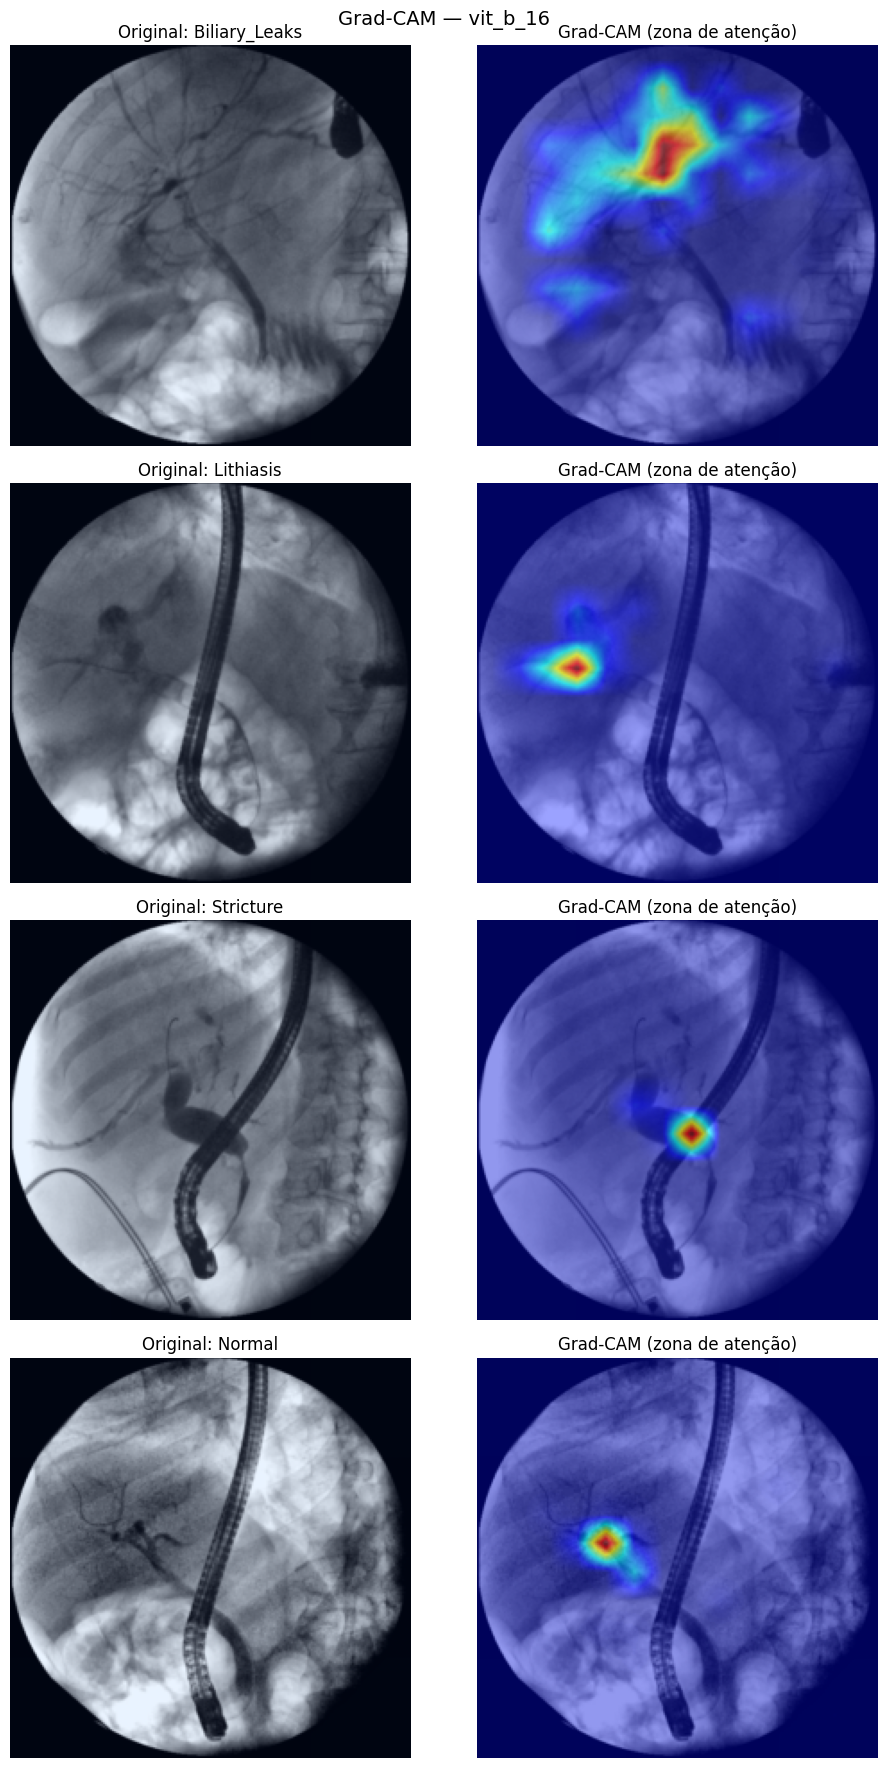

Heatmaps guardados em outputs/gradcam/


In [15]:
os.makedirs("../outputs/gradcam", exist_ok=True)
# Encontrar todos os checkpoints válidos dos 4 modelos
checkpoint_files = [str(caminho) for caminho in Path('checkpoints').glob('*.pth')]
modelos_alvo=["densenet121","efficientnet_v2_s","vit_b_16"]


if not checkpoint_files:
    print("Nenhum modelo encontrado na pasta 'checkpoints/'.")
else:
    for ckpt_path in sorted(checkpoint_files):
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=True)
        nome_modelo = ckpt['model_name']
        nome_base = next((m for m in modelos_alvo if m in nome_modelo), nome_modelo)
        # Recriar o modelo e carregar os pesos
        temp_model = get_model(nome_base, num_classes=4, feature_extracting=False)
        temp_model.load_state_dict(ckpt['state_dict'])
        temp_model.to(device)
        temp_model.eval()


        target_layers = get_target_layers_for_model(temp_model, nome_base)
        # Inicializar o interpretador usando LayerCAM em vez de Grad-CAM
        interpreter = InterpretabilityTools(temp_model, target_layers, method="layercam")


        indices_alvo = [38, 2, 0, 8]
        
        inputs_list = []
        labels_list = []
        for idx in indices_alvo:
            img_tensor, label = dataset_teste[idx]
            inputs_list.append(img_tensor)
            labels_list.append(label)
            
        inputs = torch.stack(inputs_list)
        labels = torch.stack(labels_list)

        fig, axes = plt.subplots(4, 2, figsize=(10, 18))
        fig.suptitle(f'Grad-CAM — {nome_modelo}', fontsize=14)

        for i in range(4):
            img_tensor = inputs[i:i+1].to(device)
            img_rgb = inputs[i].permute(1, 2, 0).cpu().numpy()
            img_rgb = (img_rgb - img_rgb.min()) / (img_rgb.max() - img_rgb.min() + 1e-8)
            img_rgb = img_rgb.astype(np.float32)

            classe_verdadeira = labels[i].item()
            heatmap_img = interpreter.generate_gradcam(
                img_tensor, img_rgb,
                target_category=classe_verdadeira,
                save_path=f"../outputs/gradcam/gradcam_{nome_modelo}_{i}_{CLASS_NAMES[classe_verdadeira]}.png"
            )

            axes[i][0].imshow(img_rgb, cmap='gray')
            axes[i][0].set_title(f'Original: {CLASS_NAMES[classe_verdadeira]}')
            axes[i][0].axis('off')

            axes[i][1].imshow(heatmap_img)
            axes[i][1].set_title('Grad-CAM (zona de atenção)')
            axes[i][1].axis('off')

        plt.tight_layout()
        plt.savefig(f"../outputs/gradcam/gradcam_panel_{nome_modelo}.png", dpi=150)
        plt.show()
        print("Heatmaps guardados em outputs/gradcam/")